In [7]:
import pandas as pd

df = pd.read_csv('../data/two_bedroom_home_values_zhvi.csv')
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,83344.619196,83497.156791,83684.847454,84091.160679,84557.592462,...,277241.936397,277526.843786,277198.318728,276742.253826,276169.920203,275633.122039,275112.204608,274665.813407,274477.206797,274460.149670
1,394913,1,"New York, NY",msa,NY,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.543280,501943.159082,502520.987387,503787.986518,505959.517755
2,753899,2,"Los Angeles, CA",msa,CA,169268.869371,169770.742761,170557.108176,172122.066322,173918.512499,...,739340.366867,737367.317096,732430.376873,727847.217695,723154.901146,719715.670089,717796.297400,717200.432449,717758.646596,719204.031024
3,394463,3,"Chicago, IL",msa,IL,101240.341888,101307.680756,101494.824515,101957.624150,102486.461458,...,252355.909350,253601.969084,254472.719490,255259.830574,255858.780978,256472.099230,257137.517327,257805.365792,258636.005319,259640.316581
4,394514,4,"Dallas, TX",msa,TX,69947.134256,69950.433460,69921.040192,69949.877922,70042.336016,...,231877.347334,231554.401161,230705.281883,229449.430718,227668.139913,225851.865008,224088.182881,222762.971545,221753.254434,220990.167480


In [8]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist()[:10], "...")  # Show first 10 columns
print(f"\nTotal columns: {len(df.columns)}")


Dataset Shape: (851, 315)

Column Names:
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31'] ...

Total columns: 315


In [9]:
# Check for New York in the dataset
print("Unique Region Names (first 20):")
print(df['RegionName'].unique()[:20])
print("\nChecking for New York:")
ny_regions = df[df['RegionName'].str.contains('New York', case=False, na=False)]
print(f"Found {len(ny_regions)} regions with 'New York' in name:")
print(ny_regions[['RegionName', 'StateName']].to_string())


Unique Region Names (first 20):
['United States' 'New York, NY' 'Los Angeles, CA' 'Chicago, IL'
 'Dallas, TX' 'Houston, TX' 'Washington, DC' 'Philadelphia, PA'
 'Miami, FL' 'Atlanta, GA' 'Boston, MA' 'Phoenix, AZ' 'San Francisco, CA'
 'Riverside, CA' 'Detroit, MI' 'Seattle, WA' 'Minneapolis, MN'
 'San Diego, CA' 'Tampa, FL' 'Denver, CO']

Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [10]:
import matplotlib.pyplot as plt

# Filter for New York and save to house_prices_df
house_prices_df = df[df["RegionName"] == "New York, NY"].copy()
print(f"Selected region: {house_prices_df[['RegionName', 'StateName']].values}")

# Drop non-date columns
price_data = house_prices_df.loc[:, "2000-01-31":]

# Convert to long format
price_long = price_data.melt(var_name="Date", value_name="MedianPrice")

# Convert Date column to datetime
price_long["Date"] = pd.to_datetime(price_long["Date"])

# Sort by date
price_long = price_long.sort_values("Date")

# Basic stats on the price data
print(f"\nPrice data statistics:")
print(price_long['MedianPrice'].describe())
print(f"\nDate range: {price_long['Date'].min()} to {price_long['Date'].max()}")
print(f"Total data points: {len(price_long)}")
print(f"Missing values: {price_long['MedianPrice'].isna().sum()}")

Selected region: [['New York, NY' 'NY']]

Price data statistics:
count       310.000000
mean     307278.498047
std       83733.545629
min      149779.400352
25%      258038.444729
50%      292721.634988
75%      336809.448671
max      505959.517755
Name: MedianPrice, dtype: float64

Date range: 2000-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 310
Missing values: 0


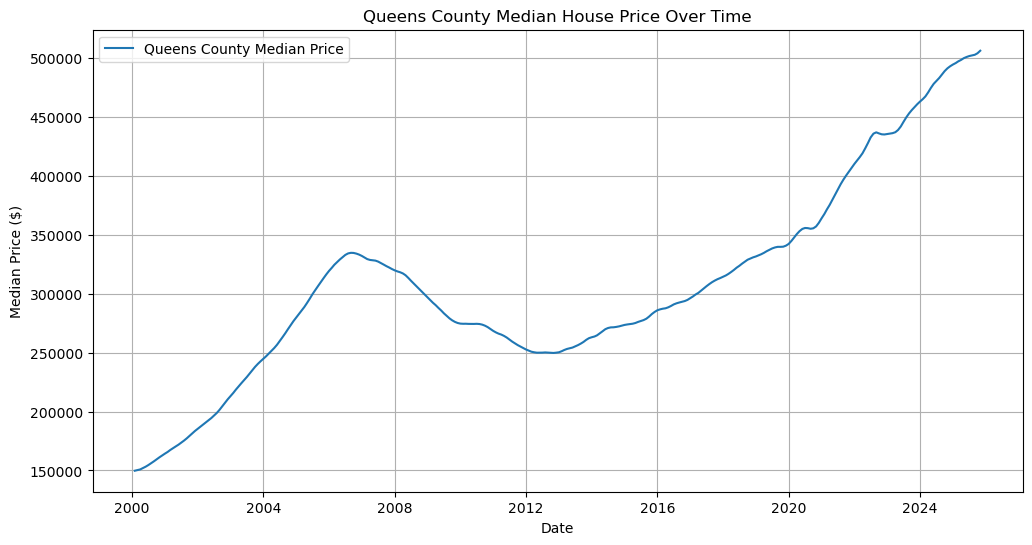

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(
    price_long["Date"], price_long["MedianPrice"], label="Queens County Median Price"
)
plt.title("Queens County Median House Price Over Time")
plt.xlabel("Date")
plt.ylabel("Median Price ($)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
house_prices_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
1,394913,1,"New York, NY",msa,NY,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755


In [13]:
house_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 1 to 1
Columns: 315 entries, RegionID to 2025-10-31
dtypes: float64(310), int64(2), object(3)
memory usage: 2.5+ KB


In [14]:
house_prices_df.describe()

,RegionID,SizeRank,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30,2000-07-31,2000-08-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
count,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
mean,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
25%,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
50%,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
75%,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
max,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755


In [15]:
# Check for duplicates
print("Duplicate rows:", house_prices_df.duplicated().sum())
print("Duplicate RegionIDs:", house_prices_df.duplicated(subset=['RegionID']).sum())

Duplicate rows: 0
Duplicate RegionIDs: 0


In [16]:
# Check for missing values
print("Total missing values:", house_prices_df.isna().sum().sum())
print("\nMissing values by column:")
print(house_prices_df.isna().sum()[house_prices_df.isna().sum() > 0])

Total missing values: 0

Missing values by column:
Series([], dtype: int64)


In [17]:
# Fill missing value using forward fill
house_prices_df = house_prices_df.fillna(method='ffill', axis=1)

C:\Users\anour\AppData\Local\Temp\ipykernel_31688\2686464598.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  house_prices_df = house_prices_df.fillna(method='ffill', axis=1)


In [18]:
# Check for missing values
print("Total missing values:", house_prices_df.isna().sum().sum())


Total missing values: 0


In [19]:
# Check what columns are in price_long
print("Columns:", price_long.columns.tolist())
print("\nFirst few rows:")
print(price_long.head())

Columns: ['Date', 'MedianPrice']

First few rows:
        Date    MedianPrice
0 2000-01-31  149779.400352
1 2000-02-29  150341.824571
2 2000-03-31  150875.340267
3 2000-04-30  151997.364168
4 2000-05-31  153210.460044


In [20]:
price_long.tail()

,Date,MedianPrice
305,2025-06-30,501426.543280
306,2025-07-31,501943.159082
307,2025-08-31,502520.987387
308,2025-09-30,503787.986518
309,2025-10-31,505959.517755


In [21]:
# Prepare for Prophet (needs 'ds' and 'y' columns)
price_long_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})

In [22]:
# ============================================
# RENTAL PRICES PREPROCESSING
# ============================================

# Read rental prices data
df_rental = pd.read_csv('../data/multifamily_rental_values_zori.csv')
df_rental.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,1158.783988,1163.832511,1171.228028,1175.383296,1179.722988,...,1759.350958,1762.586059,1764.857840,1766.494654,1767.438485,1769.352650,1771.503856,1774.625304,1777.314551,1779.303397
1,394913,1,"New York, NY",msa,NY,2264.111314,2278.386759,2291.166855,2302.839542,2309.751952,...,3245.116452,3258.020542,3269.225487,3278.078413,3285.458244,3298.403296,3318.815111,3340.302367,3357.934444,3372.411185
2,753899,2,"Los Angeles, CA",msa,CA,1671.176815,1680.585170,1693.221301,1708.879031,1722.529108,...,2651.097018,2656.867508,2659.684129,2660.694913,2660.979740,2663.835613,2665.229675,2669.891583,2672.608704,2675.925646
3,394463,3,"Chicago, IL",msa,IL,1312.935431,1313.914270,1319.733261,1322.067956,1326.647735,...,1889.175377,1898.419009,1907.877827,1917.834781,1927.050832,1936.667240,1946.329096,1955.600635,1964.607449,1971.554976
4,394514,4,"Dallas, TX",msa,TX,1040.141326,1036.535751,1039.603121,1052.215637,1058.206610,...,1522.378780,1523.219947,1522.109029,1522.868214,1520.149379,1518.771051,1516.142182,1515.500922,1515.062818,1512.591988


In [23]:
# Basic information
print("Dataset Shape:", df_rental.shape)
print("\nColumn Names (first 10):")
print(df_rental.columns.tolist()[:10])
print(f"\nTotal columns: {len(df_rental.columns)}")

Dataset Shape: (584, 135)

Column Names (first 10):
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31']

Total columns: 135


In [24]:
# Data types and info
df_rental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Columns: 135 entries, RegionID to 2025-10-31
dtypes: float64(130), int64(2), object(3)
memory usage: 616.1+ KB


In [25]:
# Check for New York
print("Checking for New York:")
ny_rental = df_rental[df_rental['RegionName'].str.contains('New York', case=False, na=False)]
print(f"Found {len(ny_rental)} regions with 'New York' in name:")
print(ny_rental[['RegionName', 'StateName']].to_string())

Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [26]:
# Filter for New York and save to rental_prices_df
rental_prices_df = df_rental[df_rental['RegionName'] == 'New York, NY'].copy()
# Or try: df_rental[df_rental['RegionName'].str.contains('New York', case=False, na=False)].copy()
print(f"Selected region: {rental_prices_df[['RegionName', 'StateName']].values}")
print(f"Shape: {rental_prices_df.shape}")

Selected region: [['New York, NY' 'NY']]
Shape: (1, 135)


In [27]:
# Check for duplicates
print("Duplicate rows:", rental_prices_df.duplicated().sum())
print("Duplicate RegionIDs:", rental_prices_df.duplicated(subset=['RegionID']).sum())

Duplicate rows: 0
Duplicate RegionIDs: 0


In [28]:
# Check for missing values
print("Total missing values:", rental_prices_df.isna().sum().sum())


Total missing values: 7


In [29]:
# Drop non-date columns
rental_price_data = rental_prices_df.loc[:, "2015-01-31":]  # Adjust start date as needed

# Convert to long format
rental_long = rental_price_data.melt(var_name="Date", value_name="RentalPrice")

# Convert Date column to datetime
rental_long["Date"] = pd.to_datetime(rental_long["Date"])

# Sort by date
rental_long = rental_long.sort_values("Date")

# Set Date as index
rental_long = rental_long.set_index("Date")

# Basic stats on the rental data
print(f"\nRental data statistics:")
print(rental_long['RentalPrice'].describe())
print(f"\nDate range: {rental_long.index.min()} to {rental_long.index.max()}")
print(f"Total data points: {len(rental_long)}")
print(f"Missing values: {rental_long['RentalPrice'].isna().sum()}")


Rental data statistics:
count     123.000000
mean     2679.910984
std       348.842085
min      2264.111314
25%      2397.551613
50%      2512.327970
75%      3026.686119
max      3372.411185
Name: RentalPrice, dtype: float64

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 130
Missing values: 7


In [30]:
# Verify ready for time series
print("Date range:", rental_long.index.min(), "to", rental_long.index.max())
print("Total points:", len(rental_long))
print("Date is datetime:", pd.api.types.is_datetime64_any_dtype(rental_long.index))
print("No missing:", rental_long['RentalPrice'].isna().sum() == 0)
print("No duplicates:", rental_long.index.duplicated().sum() == 0)
print("Is sorted:", rental_long.index.is_monotonic_increasing)

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total points: 130
Date is datetime: True
No missing: False
No duplicates: True
Is sorted: True


In [31]:
# ============================================
# MORTGAGE RATES PREPROCESSING
# ============================================

from fredapi import Fred
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Get FRED API key from environment
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

# Pull 30-Year Fixed Rate Mortgage, monthly data
mortgage = fred.get_series(
    "MORTGAGE30US", start_date="2015-01-01", end_date="2025-12-01"
)

# Convert to DataFrame
mortgage_df = mortgage.to_frame(name="mortgage_rate")
mortgage_df.index.name = "date"
mortgage_df.reset_index(inplace=True)

# Keep only data from 2015 onwards
mortgage_df = mortgage_df[mortgage_df["date"] >= "2015-01-01"]

# Convert date to datetime
mortgage_df["date"] = pd.to_datetime(mortgage_df["date"])

# Convert to monthly (take end of month value)
mortgage_df["month"] = mortgage_df["date"].dt.to_period("M")
mortgage_df_monthly = mortgage_df.groupby("month")["mortgage_rate"].last().reset_index()
mortgage_df_monthly["Date"] = mortgage_df_monthly["month"].dt.to_timestamp()
mortgage_df_monthly = mortgage_df_monthly.drop(columns=["month"])

# Set Date as index
mortgage_df_monthly = mortgage_df_monthly.set_index("Date")

print("Mortgage data statistics:")
print(mortgage_df_monthly['mortgage_rate'].describe())
print(f"\nDate range: {mortgage_df_monthly.index.min()} to {mortgage_df_monthly.index.max()}")
print(f"Total data points: {len(mortgage_df_monthly)}")


Mortgage data statistics:
count    132.000000
mean       4.694697
std        1.453832
min        2.670000
25%        3.640000
50%        4.045000
75%        6.327500
max        7.790000
Name: mortgage_rate, dtype: float64

Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Total data points: 132


In [32]:
# ============================================
# MERGE ALL DATA
# ============================================

# Reset indices to merge on Date
price_long_reset = price_long.reset_index()
rental_long_reset = rental_long.reset_index()
mortgage_reset = mortgage_df_monthly.reset_index()

# Convert all dates to end of month for alignment
price_long_reset['Date'] = pd.to_datetime(price_long_reset['Date'])
rental_long_reset['Date'] = pd.to_datetime(rental_long_reset['Date'])
mortgage_reset['Date'] = pd.to_datetime(mortgage_reset['Date'])

# Merge house prices and rental prices first (both monthly)
merged_df = pd.merge(price_long_reset, rental_long_reset, on='Date', how='outer')

# Merge with mortgage rates
merged_df = pd.merge(merged_df, mortgage_reset, on='Date', how='outer')

# Sort by date
merged_df = merged_df.sort_values('Date')

# Filter to common date range (2015 onwards where all data exists)
merged_df = merged_df[merged_df['Date'] >= '2015-01-01']

# Set Date as index
merged_df = merged_df.set_index('Date')

print("Merged dataset shape:", merged_df.shape)
print("\nFirst few rows:")
print(merged_df.head())
print("\nLast few rows:")
print(merged_df.tail())
print("\nMissing values:")
print(merged_df.isna().sum())


Merged dataset shape: (262, 4)

First few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2015-01-01    NaN            NaN          NaN           3.66
2015-01-31  180.0  273827.089475  2264.111314            NaN
2015-02-01    NaN            NaN          NaN           3.80
2015-02-28  181.0  274085.123904  2278.386759            NaN
2015-03-01    NaN            NaN          NaN           3.69

Last few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2025-09-30  308.0  503787.986518  3357.934444            NaN
2025-10-01    NaN            NaN          NaN           6.17
2025-10-31  309.0  505959.517755  3372.411185            NaN
2025-11-01    NaN            NaN          NaN           6.23
2025-12-01    NaN            NaN          NaN           6.22

Missing values:
index            132
MedianPrice      132
RentalPrice      139
mo

In [33]:
# ============================================
# TIME SERIES FORECASTING WITH PROPHET
# ============================================

from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')


In [34]:
# Prepare house prices for Prophet (needs 'ds' and 'y' columns)
house_prices_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})

# Create and fit Prophet model for house prices
model_house = Prophet()
model_house.fit(house_prices_prophet)

# Create future dataframe (5 years = 60 months, 10 years = 120 months)
future_house = model_house.make_future_dataframe(periods=120, freq='M')  # 10 years forecast

# Make forecast
forecast_house = model_house.predict(future_house)

print("House Prices Forecast:")
print(f"Forecast period: {forecast_house['ds'].min()} to {forecast_house['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_house[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


00:28:02 - cmdstanpy - INFO - Chain [1] start processing
00:28:03 - cmdstanpy - INFO - Chain [1] done processing


House Prices Forecast:
Forecast period: 2000-01-31 00:00:00 to 2035-10-31 00:00:00

Last 5 forecasted values:
            ds           yhat     yhat_lower     yhat_upper
425 2035-06-30  804324.880981  668889.746368  963902.853530
426 2035-07-31  806873.247141  667910.384680  966334.979605
427 2035-08-31  809123.094764  668799.233486  970754.600444
428 2035-09-30  811378.738834  668517.227266  976575.561390
429 2035-10-31  813779.840859  668695.458714  980915.324720


In [35]:
# Prepare rental prices for Prophet
rental_prices_prophet = rental_long.reset_index().rename(columns={'Date': 'ds', 'RentalPrice': 'y'})

# Create and fit Prophet model for rental prices
model_rental = Prophet()
model_rental.fit(rental_prices_prophet)

# Create future dataframe (10 years forecast)
future_rental = model_rental.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_rental = model_rental.predict(future_rental)

print("Rental Prices Forecast:")
print(f"Forecast period: {forecast_rental['ds'].min()} to {forecast_rental['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_rental[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


00:28:04 - cmdstanpy - INFO - Chain [1] start processing
00:28:05 - cmdstanpy - INFO - Chain [1] done processing


Rental Prices Forecast:
Forecast period: 2015-01-31 00:00:00 to 2035-10-31 00:00:00

Last 5 forecasted values:
            ds         yhat   yhat_lower   yhat_upper
245 2035-06-30  4616.409096  1020.865476  8091.094138
246 2035-07-31  4626.117835   971.259517  8155.480814
247 2035-08-31  4636.632509   923.422730  8209.426394
248 2035-09-30  4647.647156   897.282068  8260.195493
249 2035-10-31  4661.391013   862.763403  8339.920952


In [36]:
# Optional: Forecast mortgage rates
mortgage_prophet = mortgage_df_monthly.reset_index().rename(columns={'Date': 'ds', 'mortgage_rate': 'y'})

# Create and fit Prophet model for mortgage rates
model_mortgage = Prophet()
model_mortgage.fit(mortgage_prophet)

# Create future dataframe (10 years forecast)
future_mortgage = model_mortgage.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_mortgage = model_mortgage.predict(future_mortgage)

print("Mortgage Rates Forecast:")
print(f"Forecast period: {forecast_mortgage['ds'].min()} to {forecast_mortgage['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_mortgage[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


00:28:05 - cmdstanpy - INFO - Chain [1] start processing
00:28:06 - cmdstanpy - INFO - Chain [1] done processing


Mortgage Rates Forecast:
Forecast period: 2015-01-01 00:00:00 to 2035-11-30 00:00:00

Last 5 forecasted values:
            ds       yhat  yhat_lower  yhat_upper
247 2035-07-31  14.268819   12.685767   15.863592
248 2035-08-31  14.468950   12.867138   16.094692
249 2035-09-30  14.672264   12.929965   16.264794
250 2035-10-31  14.581658   12.841094   16.279842
251 2035-11-30  14.550788   12.847316   16.247003


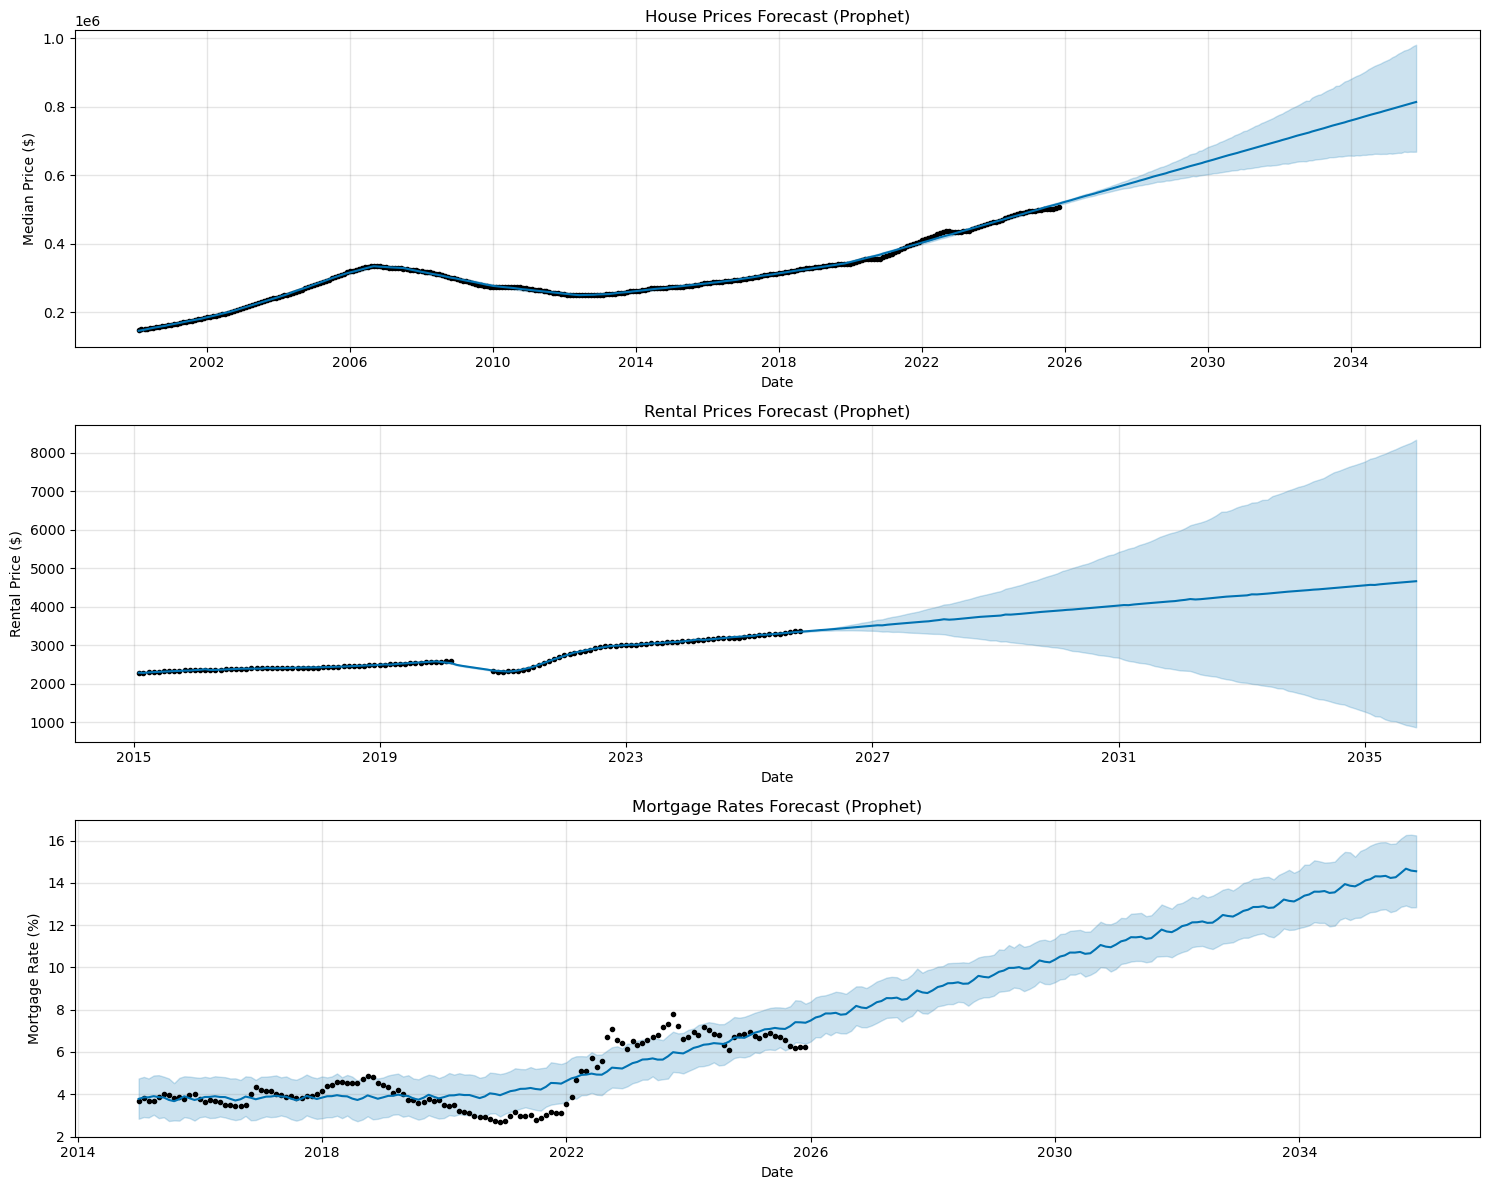

In [37]:
# Visualize forecasts
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# House prices forecast
model_house.plot(forecast_house, ax=axes[0])
axes[0].set_title('House Prices Forecast (Prophet)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Median Price ($)')

# Rental prices forecast
model_rental.plot(forecast_rental, ax=axes[1])
axes[1].set_title('Rental Prices Forecast (Prophet)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rental Price ($)')

# Mortgage rates forecast
model_mortgage.plot(forecast_mortgage, ax=axes[2])
axes[2].set_title('Mortgage Rates Forecast (Prophet)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Mortgage Rate (%)')

plt.tight_layout()
plt.show()


In [38]:
# Extract forecasted values for future dates (beyond historical data)
# Get the last date from historical data
last_historical_date_house = house_prices_prophet['ds'].max()
last_historical_date_rental = rental_prices_prophet['ds'].max()
last_historical_date_mortgage = mortgage_prophet['ds'].max()

# Filter forecasts to only future dates
forecast_house_future = forecast_house[forecast_house['ds'] > last_historical_date_house].copy()
forecast_rental_future = forecast_rental[forecast_rental['ds'] > last_historical_date_rental].copy()
forecast_mortgage_future = forecast_mortgage[forecast_mortgage['ds'] > last_historical_date_mortgage].copy()

print("Future Forecasts (beyond historical data):")
print(f"\nHouse Prices - {len(forecast_house_future)} future months")
print(f"Rental Prices - {len(forecast_rental_future)} future months")
print(f"Mortgage Rates - {len(forecast_mortgage_future)} future months")


Future Forecasts (beyond historical data):

House Prices - 120 future months
Rental Prices - 120 future months
Mortgage Rates - 120 future months
